In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

2026-04-30 11:30:07.480225: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Data Generation: Sine Curves

Generate **10,000 sine curves** of the form:

$$
x(t) = A \cdot \sin(\omega t + \phi)
$$

where the parameters are drawn from uniform distributions:

- Amplitude: $ A \sim \mathcal{U}[0.5, 1.5] $
- Frequency: $ \omega \sim \mathcal{U}[0.5, 2] $
- Phase: $ \phi \sim \mathcal{U}[0, 2\pi] $

Sample each curve at $N = 100$ equally spaced points over $t \in [0, 4\pi]$.
Your clean_curve array should have shape (10000, 100).

In [2]:
# generate dataset
num_curve=10000
A = np.random.uniform(0.5,1.5,size=(num_curve,1))
w = np.random.uniform(0.5,2,size=(num_curve,1))
phi = np.random.uniform(0,2*np.pi,size=(num_curve,1))

N = 100
t = np.linspace(0,4*np.pi,100)

clean_curve = A*np.sin(w*t + phi)
clean_curve.shape

(10000, 100)

## Add Gaussian Noise

$$
x_{\text{noisy}}(t) = x(t) + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.2
$$
Your noisy_curve array should have shape (10000, 100).

In [3]:
# generate noisy data
sigma = 0.2
err = np.random.normal(loc=0, scale=sigma, size=clean_curve.shape)

noisy_curve = clean_curve + err
noisy_curve.shape

(10000, 100)

Plot examples showing the clean and noisy curve.

Text(0.5, 1.0, 'Noisy Signals')

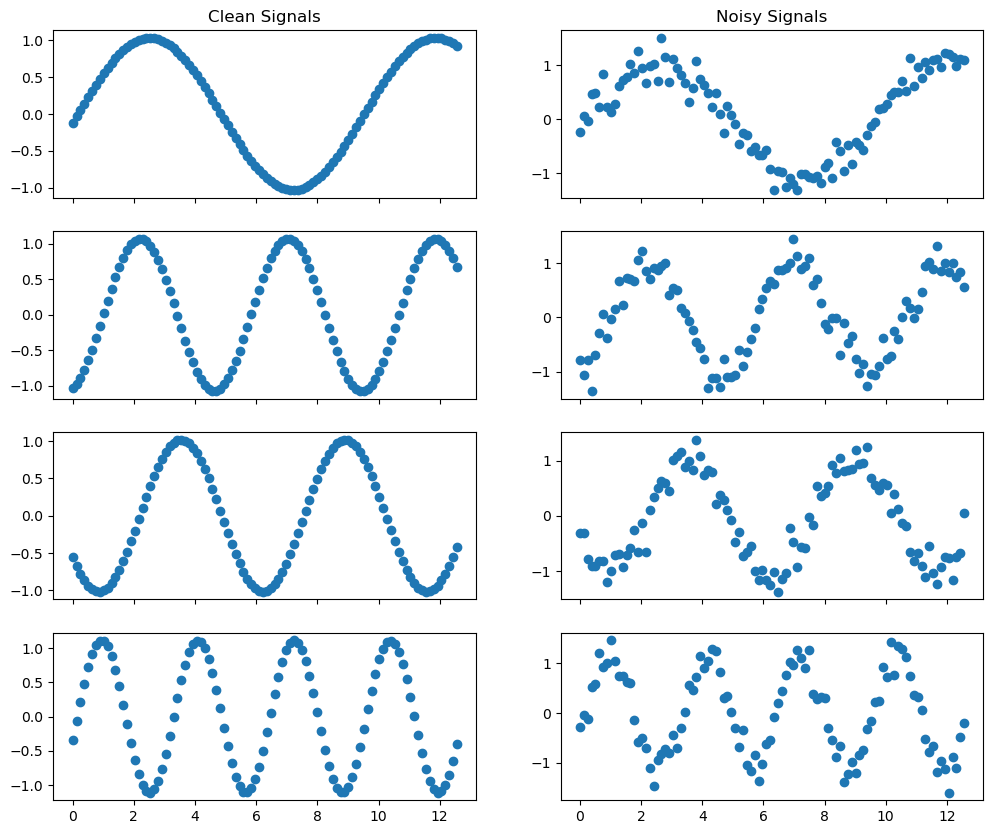

In [4]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 2, figsize=(12, 10),sharex=True)
axes[0,0].scatter(t, clean_curve[3])
axes[0,1].scatter(t, noisy_curve[3])

axes[1,0].scatter(t, clean_curve[489])
axes[1,1].scatter(t, noisy_curve[489])

axes[2,0].scatter(t, clean_curve[1864])
axes[2,1].scatter(t, noisy_curve[1864])

axes[3,0].scatter(t, clean_curve[9999])
axes[3,1].scatter(t, noisy_curve[9999])

axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
#need to figure out how to label axes: all at once or just one set?

## Dataset Split

Split into **90% training / 10% validation**.
- **Input**  (noisy_curve) : X_train -> shape (9000, 100), X_val -> shape (1000, 100)
- **Target** (clean_curve): Y_train -> shape (9000, 100), Y_val -> shape (1000, 100)

In [5]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

## Autoencoder Model

**Fully connected (dense) autoencoder**
- **Encoder** compresses the input into a low-dimensional **latent space**
- **Decoder** reconstructs the signal from the latent representation

The network is trained to minimise **mean squared error (MSE)** between the reconstructed and clean signal.

In [6]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(16, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,092 (58.95 KB)

 Trainable params: 15,092 (58.95 KB)

 Non-trainable params: 0 (0.00 B)

## Training with .fit()

.fit() trains the model. The key arguments are:

| Argument | What it means |
|---|---|
| X_train, Y_train | The data the model learns from |
| epochs | How many times the model sees the full training data |
| batch_size | How many samples to process before updating the weights |
| validation_data=(X_val, Y_val) | Data the model never trains on. It is used to check performance after each epoch |
| verbose=1 | Shows a progress bar while training; set to 0 to hide it |

After training, history stores the training loss and validation loss at every epoch:

If validation loss starts increasing while training loss keeps decreasing -> the model is **overfitting** (memorising the training data instead of generalising).

In [7]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3796 - val_loss: 0.1517
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0691 - val_loss: 0.0314
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0217 - val_loss: 0.0176
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0156 - val_loss: 0.0144
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0130 - val_loss: 0.0121
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109 - val_loss: 0.0104
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0092 - val_loss: 0.0090
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081 - val_loss: 0.0080
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074 - val_loss: 0.0076
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0069 - val_loss: 0.0070
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0065 - val_loss: 0.0068
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - val_lo

Plot the training and validation loss curves.

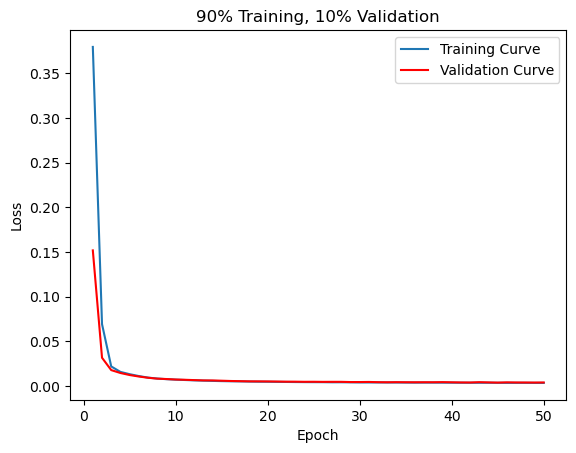

In [8]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Making Predictions with .predict()

model.predict(X) passes the input array through the trained network and returns reconstructed outputs.

In [9]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
reconstructed_y.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


(4, 100)

Plot the clean signal, noisy input, and reconstructed signal.

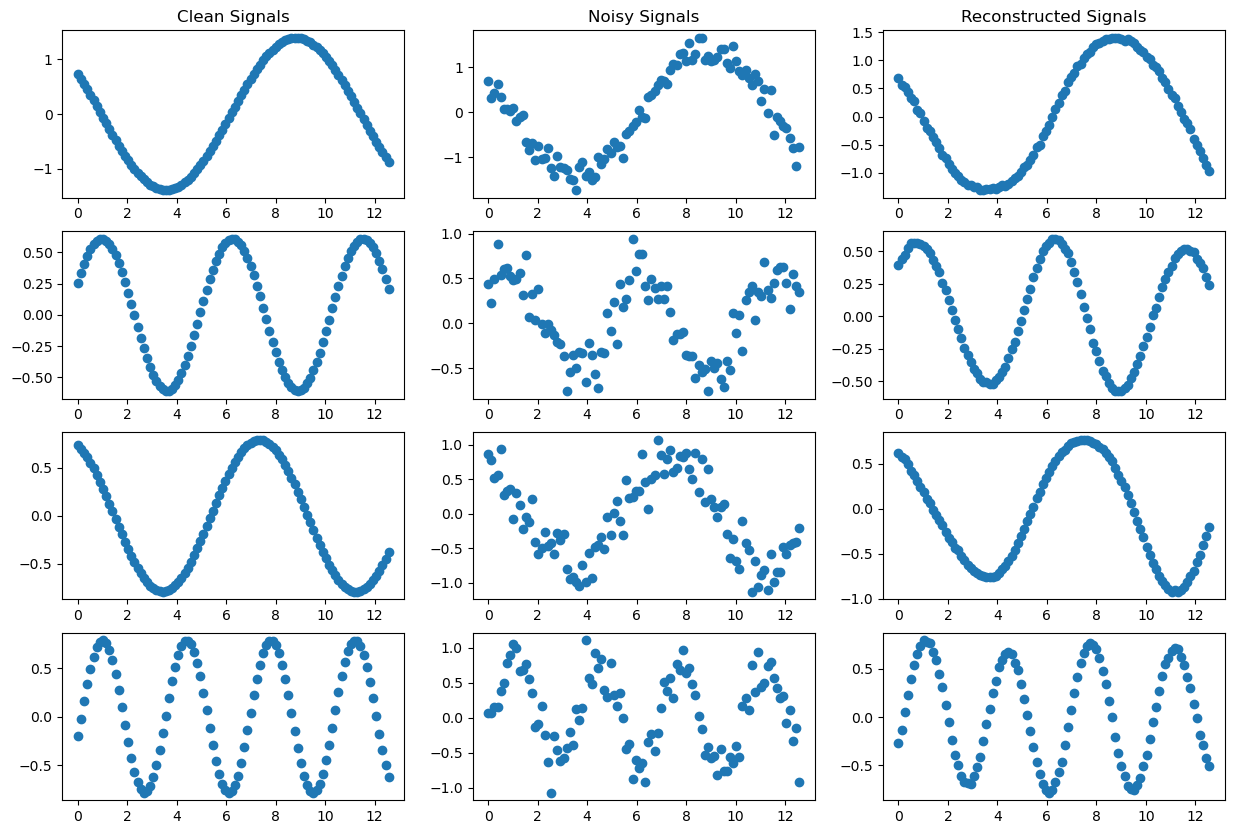

In [10]:
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
#need to figure out how to label axes: all at once or just one set?
plt.show()

# Parameter Exploration
Investigate how performance changes when modifying the following parameters. For each experiment, provide plots of training and validation loss vs. epochs. Also report the architecture and comment on whether training converges and whether you observe overfitting.

## Training data size 
- 90% training , 10% validation (baseline)
- 60% training , 40% validation
- 30% training , 70% validation
  
Discuss the effect on validation MSE and overfitting.

In [11]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.6) #70% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [12]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0033 - val_loss: 0.0033
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0033 - val_loss: 0.0034
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0034
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0032 - val_loss: 0.0033
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0034
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0033
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_loss: 0.0032
Epoch 12/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0031 - val_lo

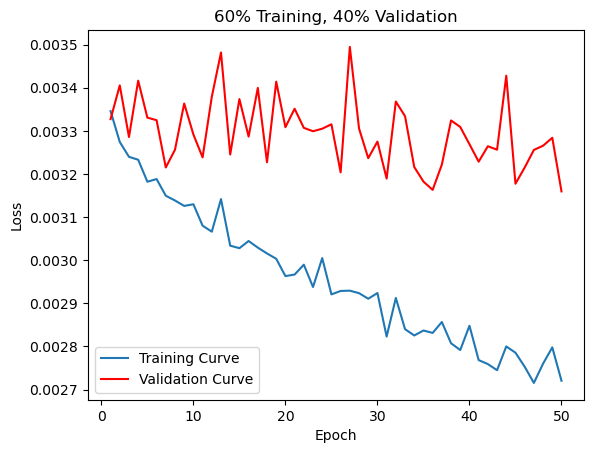

In [13]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("60% Training, 40% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [14]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.3) #70% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [15]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0029 - val_loss: 0.0029
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0031
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0031
Epoch 9/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - val_loss: 0.0030
Epoch 10/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0029
Epoch 11/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0026 - val_loss: 0.0030
Epoch 12/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027 - val_l

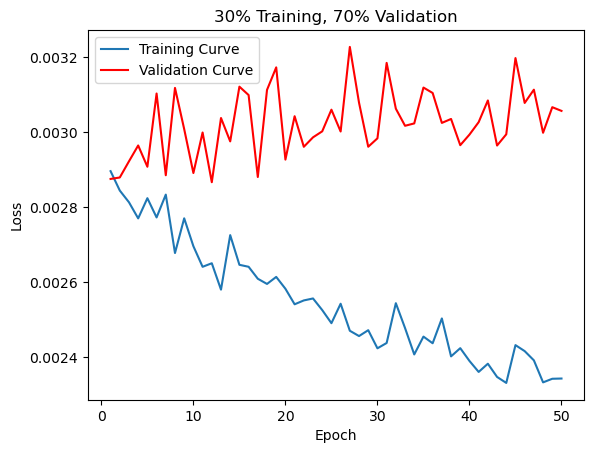

In [16]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("30% Training, 70% Validation")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Network architecture
Fix the bottleneck at 4 and experiment with different numbers of layers and neurons.

For example:

Model 1 (Baseline): $100 \rightarrow 64 \rightarrow 4 \rightarrow 64 \rightarrow 100$

Model 2 : $100 \rightarrow 80 \rightarrow 40 \rightarrow 4 \rightarrow 40 \rightarrow 80 \rightarrow 100$

Model 3 : $100 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow 4 \rightarrow 16 \rightarrow 32 \rightarrow 64 \rightarrow 100$

Record the training time and final validation MSE for each architecture.

In [17]:
#Continue using the 90%/10% for this
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [18]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(80, activation='relu'),
    Dense(40, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(40, activation='relu'),
    Dense(80, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 40)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 80)             │         3,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │         8,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,064 (90.09 KB)

 Trainable params: 23,064 (90.09 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4134 - val_loss: 0.2490
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2067 - val_loss: 0.1734
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1493 - val_loss: 0.1249
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1059 - val_loss: 0.0943
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0784 - val_loss: 0.0742
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0621 - val_loss: 0.0610
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0506 - val_loss: 0.0516
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0428 - val_loss: 0.0469
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0390 - val_loss: 0.0419
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0352 - val_loss: 0.0382
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0326 - val_loss: 0.0366
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0301 - val_lo

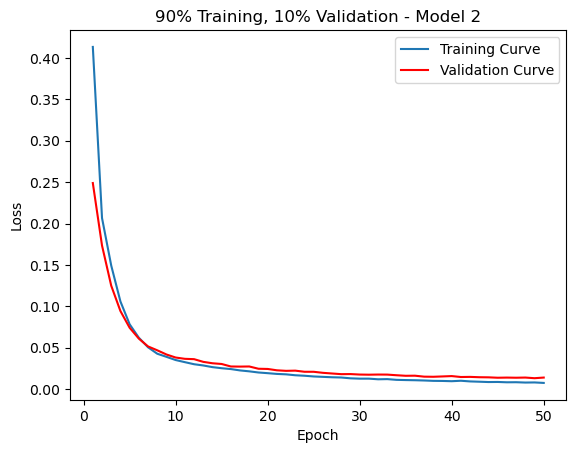

In [20]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [21]:
#Continue using the 90%/10% for this
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [22]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(16, activation='relu'),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,376 (71.78 KB)

 Trainable params: 18,376 (71.78 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.4536 - val_loss: 0.3531
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2908 - val_loss: 0.2488
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2015 - val_loss: 0.1754
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1432 - val_loss: 0.1353
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1126 - val_loss: 0.1103
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0920 - val_loss: 0.0966
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0782 - val_loss: 0.0839
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0689 - val_loss: 0.0773
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0609 - val_loss: 0.0696
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0557 - val_loss: 0.0625
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0518 - val_loss: 0.0591
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0474 - val_lo

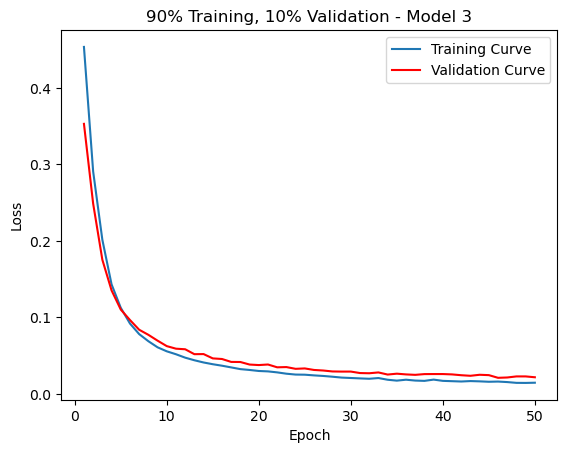

In [24]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Model 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Bottleneck Size
Fix the outer architecture (N$ \rightarrow 64 \rightarrow · \rightarrow 64 \rightarrow $N) and vary the bottleneck dimension: 16, 8, 4, 3, 2, 1. Determine the smallest bottleneck size that still reconstructs the signal accurately.

In [41]:
# dataset split
#get a different index for different sine curves
idx = np.random.permutation(num_curve) #this will shuffle through different indices
training_size = int(num_curve*0.9) #90% training - must be integer for indexing
train_idx = idx[:training_size] #the 90% training set
#train_idx.shape
val_idx = idx[training_size:] #the remaning 1000 (10%)
#val_idx.shape

#input
x_train = noisy_curve[train_idx]
x_val = noisy_curve[val_idx]

#target
y_train = clean_curve[train_idx]
y_val = clean_curve[val_idx]

In [42]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(8, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,060 (54.92 KB)

 Trainable params: 14,060 (54.92 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.3919 - val_loss: 0.1755
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0862 - val_loss: 0.0542
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0405 - val_loss: 0.0297
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0242 - val_loss: 0.0206
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0175 - val_loss: 0.0161
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0149 - val_loss: 0.0147
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0134 - val_loss: 0.0132
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0124 - val_loss: 0.0129
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0116 - val_loss: 0.0119
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109 - val_loss: 0.0116
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0104 - val_loss: 0.0109
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0099 - val_lo

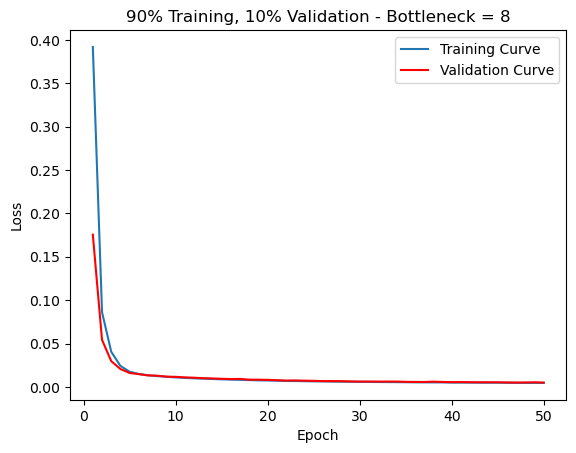

In [44]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 8")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


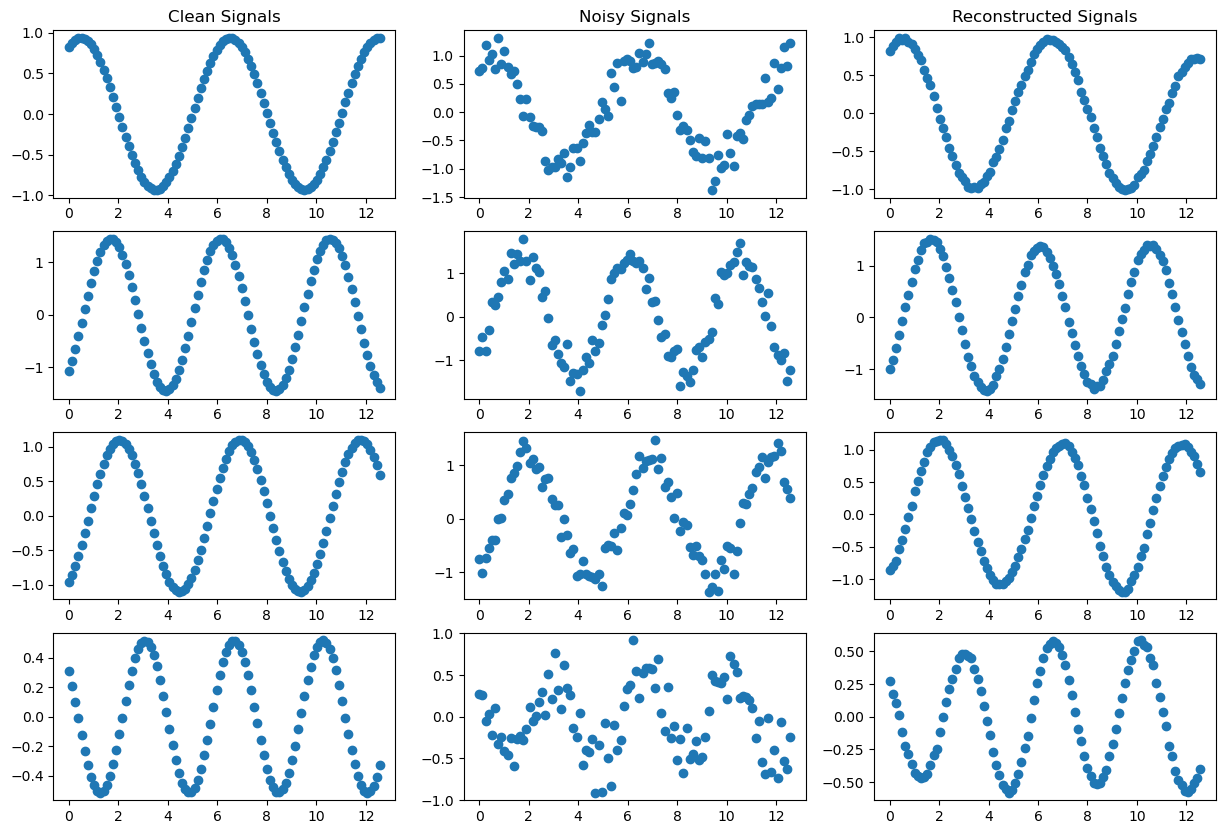

In [45]:
examples = [0, 1, 2, 3]

reconstructed_y = autoencoder.predict(x_val[examples]) # Returns shape (4, 100)
# plot clean vs noisy examples
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
for i, idx in enumerate(examples):
    axes[i,0].scatter(t,y_val[idx]) #clean
    axes[i,1].scatter(t,x_val[idx]) #noisy
    axes[i,2].scatter(t,reconstructed_y[idx]) #reconstructed
axes[0,0].set_title("Clean Signals")
axes[0,1].set_title("Noisy Signals")
axes[0,2].set_title("Reconstructed Signals")
#need to figure out how to label axes: all at once or just one set?
plt.show()

In [29]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(4, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 4)              │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,544 (52.91 KB)

 Trainable params: 13,544 (52.91 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4272 - val_loss: 0.2964
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2424 - val_loss: 0.2056
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1818 - val_loss: 0.1518
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1387 - val_loss: 0.1142
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1057 - val_loss: 0.0855
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0858 - val_loss: 0.0714
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0737 - val_loss: 0.0629
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0655 - val_loss: 0.0566
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0591 - val_loss: 0.0512
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0532 - val_loss: 0.0462
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0487 - val_loss: 0.0423
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0448 - val_lo

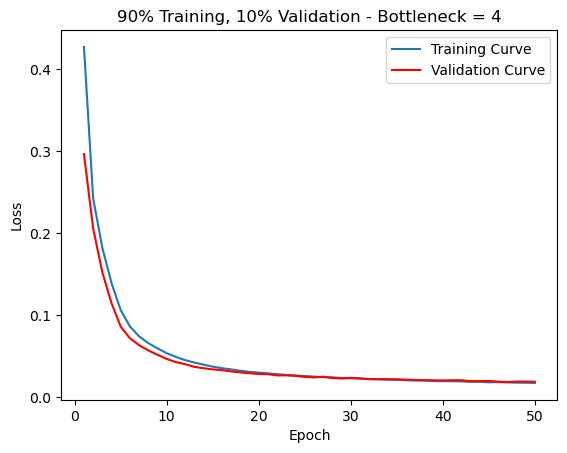

In [31]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 4")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [32]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(3, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 3)              │           195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,415 (52.40 KB)

 Trainable params: 13,415 (52.40 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4591 - val_loss: 0.3667
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3155 - val_loss: 0.2999
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2781 - val_loss: 0.2703
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2491 - val_loss: 0.2411
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2235 - val_loss: 0.2170
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1998 - val_loss: 0.1918
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1777 - val_loss: 0.1725
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1648 - val_loss: 0.1605
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1540 - val_loss: 0.1493
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1462 - val_loss: 0.1431
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1399 - val_loss: 0.1376
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1350 - val_lo

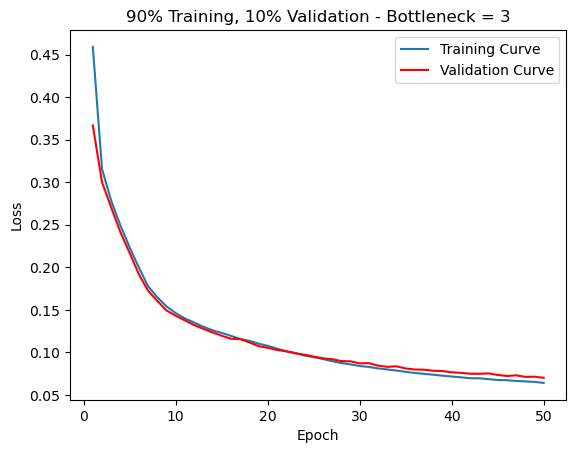

In [34]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 3")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [35]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(2, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,286 (51.90 KB)

 Trainable params: 13,286 (51.90 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.4728 - val_loss: 0.4278
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3983 - val_loss: 0.3885
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3746 - val_loss: 0.3689
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3543 - val_loss: 0.3503
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3351 - val_loss: 0.3370
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3185 - val_loss: 0.3176
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2992 - val_loss: 0.2976
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2849 - val_loss: 0.2869
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2775 - val_loss: 0.2802
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2719 - val_loss: 0.2737
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2673 - val_loss: 0.2703
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2634 - val_lo

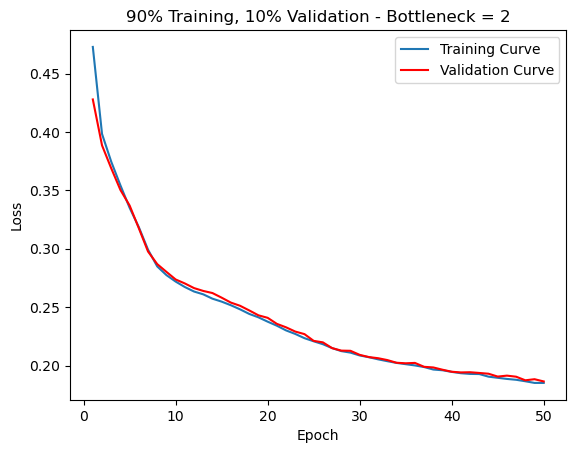

In [37]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 2")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

In [38]:
autoencoder = Sequential([
    Input(shape=(N,)),
    Dense(64, activation='relu'),
    Dense(1, activation='relu'),  # latent (bottleneck) layer
    Dense(64, activation='relu'),
    Dense(N,  activation='linear') # output layer
])

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 100)            │         6,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.39 KB)

 Trainable params: 13,157 (51.39 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = autoencoder.fit(
    x_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(x_val, y_val),
    verbose=1
)

# extract loss values for plotting
train_loss   = history.history['loss'] # training loss per epoch
val_loss     = history.history['val_loss'] # validation loss per epoch
epochs_range = range(1, len(train_loss) + 1)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5097 - val_loss: 0.4978
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4838 - val_loss: 0.4889
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4766 - val_loss: 0.4828
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4710 - val_loss: 0.4781
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4661 - val_loss: 0.4730
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4603 - val_loss: 0.4661
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4528 - val_loss: 0.4577
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4449 - val_loss: 0.4514
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4395 - val_loss: 0.4478
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4364 - val_loss: 0.4455
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4348 - val_loss: 0.4450
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4336 - val_lo

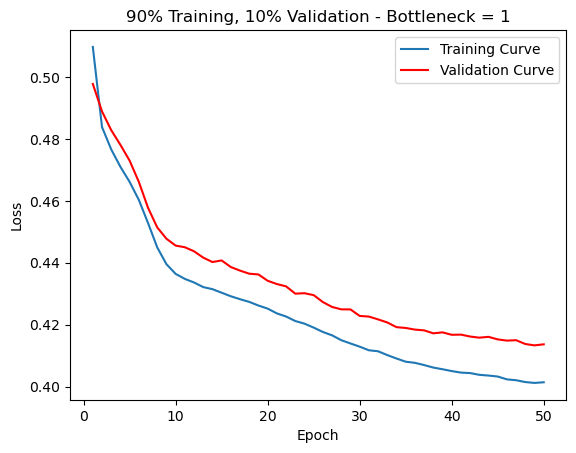

In [40]:
# plot loss curves
plt.plot(epochs_range,train_loss,label="Training Curve")
plt.plot(epochs_range,val_loss, color="red",label="Validation Curve")
plt.title("90% Training, 10% Validation - Bottleneck = 1")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend()

## Noise models
Instead of Gaussian noise, test Laplace noise.